In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
X = np.random.randn(100, 1)

noise = np.random.randn(100, 1) * 0.1
y = 3 * X + 2 + noise

w = np.zeros([1,1])
b = 0

In [31]:
def predict(X, w, b):
    return X @ w + b

In [32]:
def mse_loss(y_predict, y):
    return np.sum(1/y.shape[0] * (y_predict - y) ** 2)

In [33]:
def compute_gradients(X, y_predict, y):
    w_gradient = 2/X.shape[0] * (X.T @ (y_predict - y))
    b_gradient = 2/X.shape[0] * np.sum(y_predict - y)

    return w_gradient, b_gradient

In [35]:
def fit(X, y, epoch, lr):
    w = np.zeros([X.shape[1], 1])
    b = 0

    loss_list = []

    for i in range(epoch):

        y_predict = predict(X, w, b)

        loss = mse_loss(y_predict, y)

        loss_list.append(loss)
        
        w_gradient, b_gradient = compute_gradients(X, y_predict, y)

        w -= lr * w_gradient
        b -= lr * b_gradient

        if i % 100 == 0:
            print(loss)

    return w, b, loss_list

In [36]:
w, b, loss_list = fit(X, y, 1000, 0.01)

print(w, b)

12.947235251527937
0.2521260276966136
0.016022328440353527
0.011506222906261463
0.011417192025409115
0.011415382323155391
0.01141534444817746
0.01141534363438057
0.011415343616497556
0.011415343616097303
[[3.01103478]] 2.0073253336967425


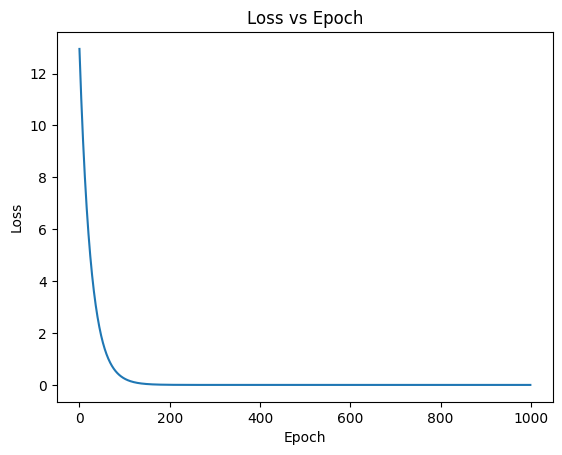

In [37]:
plt.plot(loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.show()

In [41]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load
data = fetch_california_housing()
X_cal, y_cal = data.data, data.target.reshape(-1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_cal, y_cal, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
w, b, loss_history = fit(X_train_scaled, y_train, epoch=1000, lr=0.01)
y_pred_mine = predict(X_test_scaled, w, b)
rmse_mine = np.sqrt(mse_loss(y_pred_mine, y_test))

#sklearn
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred_sk = model.predict(X_test_scaled)
rmse_sk = np.sqrt(mse_loss(y_pred_sk, y_test))

print(f"My RMSE: {rmse_mine}")
print(f"Sklearn RMSE: {rmse_sk}")


5.629742323103131
0.7103658676026788
0.5953130085792435
0.5732304657671403
0.5584093310450804
0.5476601015303804
0.5398283477804549
0.5341100200814504
0.5299255181901082
0.5268559059337551
My RMSE: 0.7447009510742247
Sklearn RMSE: 0.7455813830127763
